In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/telco_churn.csv")
print(df.shape)
df.head()

(5043, 22)


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,False,True,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000381469727,False
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,True,False,True,False,False,False,One year,False,Mailed check,56.950001,1889.5,False
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,True,True,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.1500015258789,True
3,3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,True,False,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,False,False,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.64999389648438,True


In [11]:
df.columns.tolist()

['Unnamed: 0',
 'customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   str    
 2   gender            5043 non-null   str    
 3   SeniorCitizen     5043 non-null   str    
 4   Partner           5043 non-null   str    
 5   Dependents        5043 non-null   str    
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   str    
 8   MultipleLines     4774 non-null   str    
 9   InternetService   5043 non-null   str    
 10  OnlineSecurity    4392 non-null   str    
 11  OnlineBackup      4392 non-null   str    
 12  DeviceProtection  4392 non-null   str    
 13  TechSupport       4392 non-null   str    
 14  StreamingTV       4392 non-null   str    
 15  StreamingMovies   4392 non-null   str    
 16  Contract          5043 non-null   str    
 17  Paperl

In [9]:
df.isna().sum()

Unnamed: 0            0
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       269
InternetService       0
OnlineSecurity      651
OnlineBackup        651
DeviceProtection    651
TechSupport         651
StreamingTV         651
StreamingMovies     651
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          5
Churn                 1
dtype: int64

In [6]:
df["Churn"].value_counts(normalize=True)

Churn
False    0.440103
No       0.294923
True     0.154701
Yes      0.110274
Name: proportion, dtype: float64

In [7]:
df.describe()

,Unnamed: 0,tenure,MonthlyCharges
count,5043.000000,5043.000000,5043.000000
mean,1305.651993,32.576641,65.090214
std,801.484415,24.529807,30.068133
min,0.000000,0.000000,18.400000
25%,630.000000,9.000000,35.775000
50%,1260.000000,29.000000,70.550003
75%,1890.500000,56.000000,90.050003
max,2999.000000,72.000000,118.650002


In [8]:
df["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [12]:
# 2a — ver o alvo em bruto, incluindo ausentes
df["Churn"].value_counts(dropna=False)

Churn
False    2219
No       1487
True      780
Yes       556
NaN         1
Name: count, dtype: int64

In [13]:
# 2b — há clientes/linhas duplicadas? (confirma a suspeita de concatenação)
print("customerID duplicados:", df["customerID"].duplicated().sum())
print("linhas totalmente duplicadas:", df.duplicated().sum())

customerID duplicados: 0
linhas totalmente duplicadas: 0


In [14]:
# 4 — testar a hipótese do "ausente estrutural"
print(df["InternetService"].value_counts(dropna=False))
print(df["PhoneService"].value_counts(dropna=False))

InternetService
Fiber optic    2248
DSL            1715
No             1080
Name: count, dtype: int64
PhoneService
True     2731
Yes      1823
False     269
No        220
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt
import os
os.makedirs("../reports/figures", exist_ok=True)  # cria reports/figures se não existir

Matplotlib is building the font cache; this may take a moment.


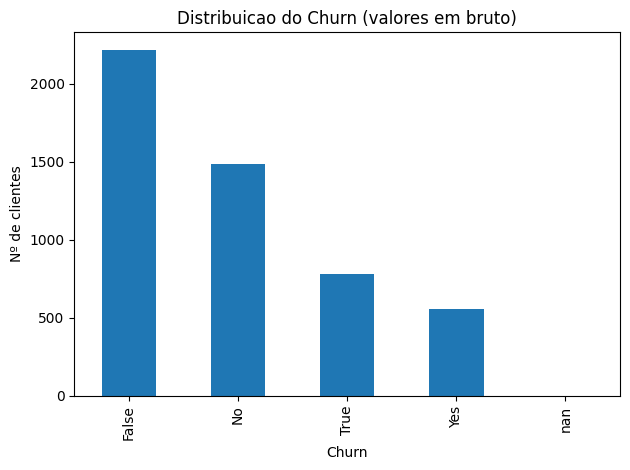

In [18]:
df["Churn"].value_counts(dropna=False).plot(kind="bar")
plt.title("Distribuicao do Churn (valores em bruto)")
plt.ylabel("Nº de clientes")
plt.tight_layout()
plt.savefig("../reports/figures/churn_distribution_raw.png")
plt.show()

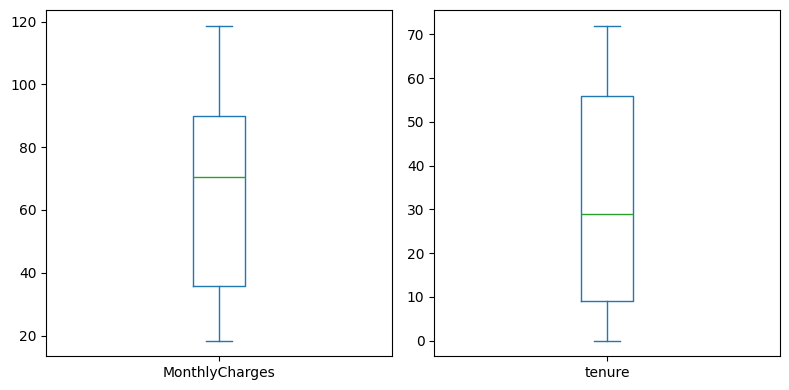

In [19]:
df[["MonthlyCharges", "tenure"]].plot(kind="box", subplots=True, layout=(1,2), figsize=(8,4))
plt.tight_layout()
plt.savefig("../reports/figures/numeric_boxplots.png")
plt.show()